In [1]:
import pandas as pd

from tornadoq.benchmark_models import get_binary_estimators, get_multiclass_estimators
from tornadoq.preprocess import PreprocessConfig, split_xy, build_preprocessor
from tornadoq.evaluate_classical_benchmarks import (
    cv_evaluate_binary,
    cv_evaluate_multiclass,
    fit_and_eval_binary_many,
    fit_and_eval_multiclass_many,
)
from tornadoq.io import load_train_val_test
from tornadoq.config import CVConfig


models_to_test = ["xgb"]

TRAIN = "../Data/NOAA/train.csv"
VAL   = "../Data/NOAA/val.csv"
TEST  = "../Data/NOAA/test.csv"

df_tr, df_va, df_te = load_train_val_test(TRAIN, VAL, TEST)
cv_cfg = CVConfig(folds=5, shuffle=True, random_state=42, repeats=1)

# =========================
# BINARY
# =========================
X_tr_b, X_va_b, y_tr_b, y_va_b = split_xy(df_tr, df_va, target="ef_binary")
_,     X_te_b, _,     y_te_b   = split_xy(df_tr, df_te, target="ef_binary")

pre_b = build_preprocessor(X_tr_b, PreprocessConfig(scaler="minmax"))
binary_models = get_binary_estimators(pre_b, use_smote=True, models_to_test=models_to_test)

binary_cv_tbl = cv_evaluate_binary(binary_models, X_tr_b, y_tr_b, cv_cfg)
binary_best = binary_cv_tbl.index[0]

# Evaluate best on VAL
binary_val_res = fit_and_eval_binary_many(
    {"best": binary_models[binary_best]},
    X_tr_b, y_tr_b,
    X_va_b, y_va_b,
)["best"]

# Final: fit on TRAIN+VAL, evaluate TEST
X_trva_b = pd.concat([X_tr_b, X_va_b], axis=0, ignore_index=True)
y_trva_b = pd.concat([y_tr_b, y_va_b], axis=0, ignore_index=True)

binary_test_res = fit_and_eval_binary_many(
    {"best": binary_models[binary_best]},
    X_trva_b, y_trva_b,
    X_te_b, y_te_b,
)["best"]

binary_best, binary_val_res, binary_test_res


# =========================
# MULTICLASS
# =========================
X_tr_m, X_va_m, y_tr_m, y_va_m = split_xy(df_tr, df_va, target="ef_class")
_,     X_te_m, _,     y_te_m   = split_xy(df_tr, df_te, target="ef_class")

pre_m = build_preprocessor(X_tr_m, PreprocessConfig(scaler="minmax"))
multiclass_models = get_multiclass_estimators(preprocessor=pre_m, use_smote=True, models_to_test=models_to_test)

multiclass_cv_tbl = cv_evaluate_multiclass(multiclass_models, X_tr_m, y_tr_m, cv_cfg)
multiclass_best = multiclass_cv_tbl.index[0]

multiclass_val_res = fit_and_eval_multiclass_many(
    {"best": multiclass_models[multiclass_best]},
    X_tr_m, y_tr_m,
    X_va_m, y_va_m,
)["best"]

X_trva_m = pd.concat([X_tr_m, X_va_m], axis=0, ignore_index=True)
y_trva_m = pd.concat([y_tr_m, y_va_m], axis=0, ignore_index=True)

multiclass_test_res = fit_and_eval_multiclass_many(
    {"best": multiclass_models[multiclass_best]},
    X_trva_m, y_trva_m,
    X_te_m, y_te_m,
)["best"]

multiclass_best, multiclass_val_res, multiclass_test_res


('xgb',
 {'test_accuracy': 0.48783910196445274,
  'report': '              precision    recall  f1-score   support\n\n        EF-0       0.68      0.58      0.63      1032\n        EF-1       0.49      0.45      0.47       792\n        EF-2       0.22      0.27      0.24       250\n        EF-3       0.08      0.28      0.13        54\n        EF-4       0.09      0.44      0.15         9\n        EF-5       0.00      0.00      0.00         1\n\n    accuracy                           0.49      2138\n   macro avg       0.26      0.34      0.27      2138\nweighted avg       0.54      0.49      0.51      2138\n'},
 {'test_accuracy': 0.49438727782974745,
  'report': '              precision    recall  f1-score   support\n\n        EF-0       0.66      0.60      0.63       985\n        EF-1       0.53      0.42      0.47       839\n        EF-2       0.25      0.35      0.29       240\n        EF-3       0.12      0.37      0.19        57\n        EF-4       0.12      0.53      0.20        

In [2]:
import pandas as pd
from sklearn.base import clone
from tornadoq.config import CVConfig
from tornadoq.evaluate_classical_benchmarks import fit_and_eval_binary

# --- CV on TRAIN only ---
binary_cv_tbl = cv_evaluate_binary(binary_models, X_tr_b, y_tr_b, CVConfig(folds=5))

metric = "cv_roc_auc_mean"  # <-- change to whatever column cv_evaluate_binary returns
binary_best = binary_cv_tbl.sort_values(metric, ascending=False).index[0]

# --- Evaluate chosen model on VAL ---
val_res = fit_and_eval_binary(
    clone(binary_models[binary_best]),
    X_tr_b, y_tr_b,
    X_va_b, y_va_b,
)

# --- Final: fit on TRAIN+VAL, report TEST ---
X_trva_b = pd.concat([X_tr_b, X_va_b], axis=0, ignore_index=True)
y_trva_b = pd.concat([y_tr_b, y_va_b], axis=0, ignore_index=True)

test_res = fit_and_eval_binary(
    clone(binary_models[binary_best]),
    X_trva_b, y_trva_b,
    X_te_b, y_te_b,
)

binary_best, val_res, test_res


('xgb',
 {'test_roc_auc': 0.6889308512124259,
  'test_accuracy': 0.745088868101029,
  'report': '               precision    recall  f1-score   support\n\n Weak (EF0-1)       0.89      0.80      0.84      1824\nStrong (EF2+)       0.28      0.45      0.34       314\n\n     accuracy                           0.75      2138\n    macro avg       0.58      0.62      0.59      2138\n weighted avg       0.80      0.75      0.77      2138\n'},
 {'test_roc_auc': 0.746961951055984,
  'test_accuracy': 0.7413470533208606,
  'report': '               precision    recall  f1-score   support\n\n Weak (EF0-1)       0.91      0.77      0.84      1824\nStrong (EF2+)       0.30      0.56      0.39       314\n\n     accuracy                           0.74      2138\n    macro avg       0.60      0.67      0.61      2138\n weighted avg       0.82      0.74      0.77      2138\n'})

In [ ]:
import pandas as pd
from sklearn.base import clone
from tornadoq.config import CVConfig
from tornadoq.evaluate_classical_benchmarks import fit_and_eval_multiclass

# --- CV on TRAIN only ---
multiclass_cv_tbl = cv_evaluate_multiclass(
    multiclass_models,
    X_tr_m, y_tr_m,
    CVConfig(folds=5)
)
multiclass_cv_tbl.head()

metric = "cv_acc_mean"  # change if your CV table uses a different column
multiclass_best = multiclass_cv_tbl.sort_values(metric, ascending=False).index[0]

# --- Evaluate chosen model on VAL ---main/full_pipeline_NOAA_dataset.ipynbIn 
val_res_multi = fit_and_eval_multiclass(
    clone(multiclass_models[multiclass_best]),
    X_tr_m, y_tr_m,
    X_va_m, y_va_m,
)

# --- Final: fit on TRAIN+VAL, report TEST ---
X_trva_m = pd.concat([X_tr_m, X_va_m], axis=0, ignore_index=True)
y_trva_m = pd.concat([y_tr_m, y_va_m], axis=0, ignore_index=True)

test_res_multi = fit_and_eval_multiclass(
    clone(multiclass_models[multiclass_best]),
    X_trva_m, y_trva_m,
    X_te_m, y_te_m,
)

multiclass_best, val_res_multi, test_res_multi


('xgb',
 {'test_accuracy': 0.48783910196445274,
  'report': '              precision    recall  f1-score   support\n\n        EF-0       0.68      0.58      0.63      1032\n        EF-1       0.49      0.45      0.47       792\n        EF-2       0.22      0.27      0.24       250\n        EF-3       0.08      0.28      0.13        54\n        EF-4       0.09      0.44      0.15         9\n        EF-5       0.00      0.00      0.00         1\n\n    accuracy                           0.49      2138\n   macro avg       0.26      0.34      0.27      2138\nweighted avg       0.54      0.49      0.51      2138\n'},
 {'test_accuracy': 0.49438727782974745,
  'report': '              precision    recall  f1-score   support\n\n        EF-0       0.66      0.60      0.63       985\n        EF-1       0.53      0.42      0.47       839\n        EF-2       0.25      0.35      0.29       240\n        EF-3       0.12      0.37      0.19        57\n        EF-4       0.12      0.53      0.20        

In [4]:
from torch.utils.data import DataLoader
from tornadoq.preprocessing import ClassificationDataset, Preprocess, DataMaker

withShadows = True


# Create pandas dataframes
df_train, df_test, df_val = DataMaker(TRAIN, TEST, VAL, withShadows = True, output_filename="NOAA_shadow_enhanced.csv")

print()
print("List:",df_train.columns.tolist())

classifier = 'binary'

# Preprocessing
X_train, y_train, X_test, y_test, X_val, y_val = Preprocess(df_train, df_test, df_val, balance = 'smote', classes = classifier)

print()
print("Y:vals", y_val)


train_data = ClassificationDataset(X_train, y_train)
validation_data = ClassificationDataset(X_val, y_val)
test_data = ClassificationDataset(X_test, y_test)

# Dataloaders
train_loader = DataLoader(train_data, batch_size=64, shuffle=True, drop_last=True)
val_loader = DataLoader(validation_data, batch_size=64, shuffle=False, drop_last=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False, drop_last=True)

print("\nNumber of training samples:", len(train_data))
print("Number of validation samples:", len(validation_data))
print("Number of test samples:", len(test_data))

✓ Combined data saved: 14248 rows, 42 columns

List: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 'cape', 'cin', 'dewpoint_2m', 'temp_2m', 'tcwv', 'surface_pressure', 'shear_0_1km', 'shear_0_3km', 'ef_binary', 'ef_class']

Y:vals 0       0
1       0
2       0
3       0
4       0
       ..
2133    0
2134    0
2135    0
2136    0
2137    1
Name: ef_binary, Length: 2138, dtype: int64

Number of training samples: 17020
Number of validation samples: 2138
Number of test samples: 2138


<class 'tornadoq.models.BinaryDNN'>
Epoch [1] had best val_metric
Epoch [1] had best val_Loss
Epoch [2] had best val_metric
Epoch [3] had best val_metric
Epoch [4] had best val_metric
Epoch [4] had best val_Loss
Epoch [5/45] | Train Loss: 0.6444 | Train Acc: 0.6245 | Val Loss: 0.6429 | Val Acc: 0.6023
Epoch [7] had best val_metric
Epoch [7] had best val_Loss
Epoch [10/45] | Train Loss: 0.6407 | Train Acc: 0.6320 | Val Loss: 0.7029 | Val Acc: 0.5687
Epoch [13] had best val_Loss
Epoch [15/45] | Train Loss: 0.6362 | Train Acc: 0.6330 | Val Loss: 0.5810 | Val Acc: 0.6979
Epoch [20/45] | Train Loss: 0.6410 | Train Acc: 0.6268 | Val Loss: 0.6005 | Val Acc: 0.7121
Epoch [20] had best val_metric
Epoch [25/45] | Train Loss: 0.6329 | Train Acc: 0.6336 | Val Loss: 0.5438 | Val Acc: 0.7562
Epoch [25] had best val_metric
Epoch [25] had best val_Loss
Epoch [30/45] | Train Loss: 0.6339 | Train Acc: 0.6320 | Val Loss: 0.5555 | Val Acc: 0.6922
Epoch [33] had best val_metric
Epoch [35/45] | Train Loss: 

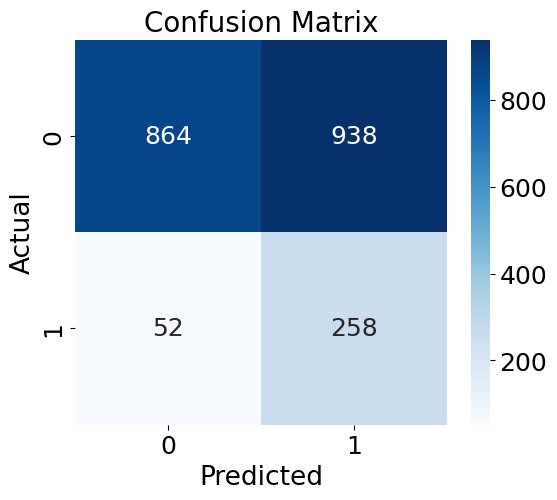

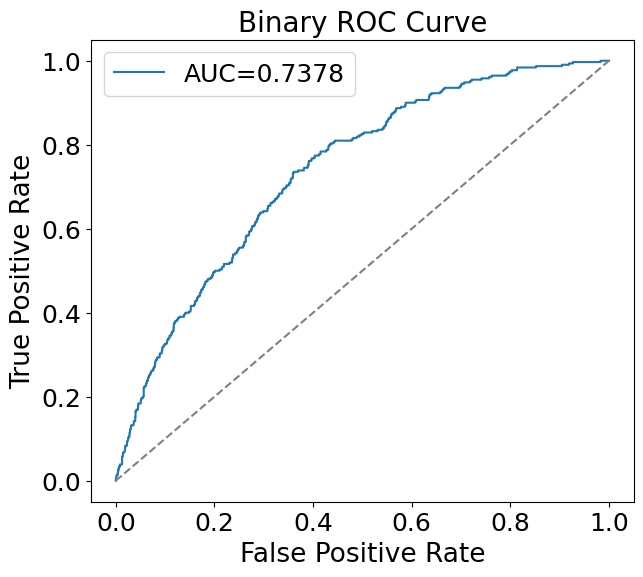

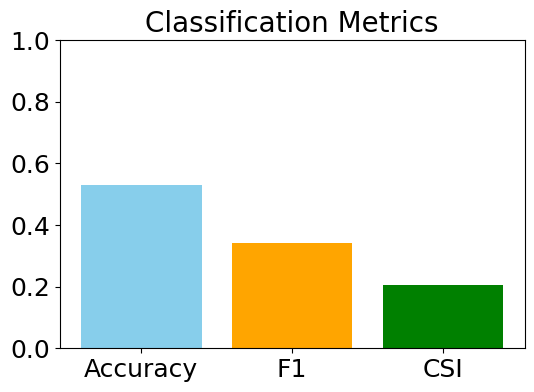

In [5]:
from tornadoq.train import train
from tornadoq.models import InitializeModel
from tornadoq.loadSaveEval import eval_model, save

# Choose model and hyperparameters
model = "DNN"
# model = "StronglyEntangling"
# model = "RandomLayer"
n_epochs = 45
lr = .01
input_size = len(X_train.columns)


# Initialize, train, and evaluate model
model = InitializeModel(model, load_path = None, classifier = classifier, input_size = input_size)
print(type(model))
train(model = model, n_epochs = n_epochs, lr = lr, train_loader = train_loader, val_loader = val_loader, classifier = classifier)
eval_model(model = model, test_loader = test_loader, classifier = classifier, fontsize = 18)

# Training automatically saves the best performing model paramters
# Optionally, save the final model parameters
# save(model = model, save_path = None)
# Or load a previously trained model
# load(model = model, load_path = "")